Initially created tasks:
  Task ID Task Position (x, y)  Urgency  Duration (min)
0      T1              (6, 44)        5              16
1      T2             (63, 13)        6              18
2      T3             (13, 14)        4              10
3      T4             (23, 36)        7              27
4      T5             (40, 14)        9              22
5      T6              (86, 2)        8              25
6      T7              (2, 88)        6              22
7      T8             (17, 80)        8              11
8      T9             (85, 24)        0              30
9     T10             (60, 99)        1              27

Time step: 0

Time step: 1

Time step: 2

Time step: 3

Time step: 4

Time step: 5
New dynamic task created: {'Task ID': 'D1', 'Task Position (x, y)': (55, 62), 'Urgency': 2, 'Duration (min)': 22}

Time step: 6
New dynamic task created: {'Task ID': 'D2', 'Task Position (x, y)': (82, 88), 'Urgency': 4, 'Duration (min)': 28}

Time step: 7
New dynamic task cr

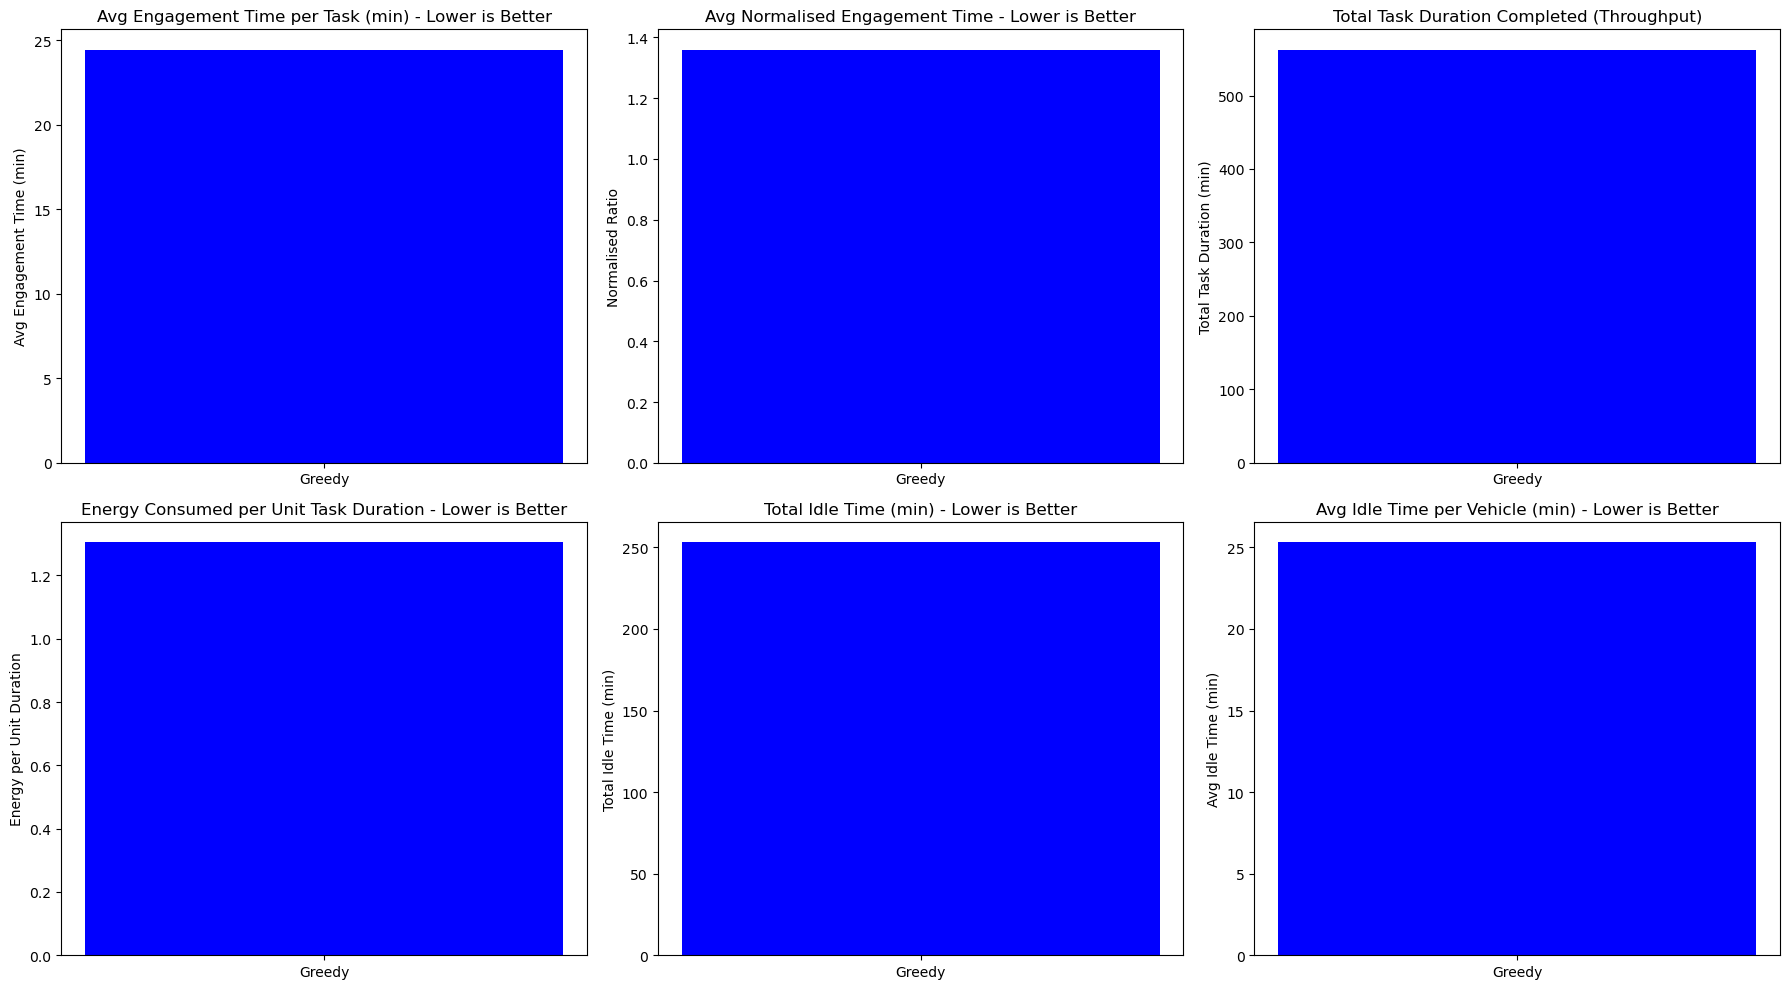

In [2]:
# fleet_ComparisonDynamic.ipynb
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import fleet_greedy_allocationDynamic as ga
import DataGenerationDynamic as dgd 

# Simulation parameters
TIME_STEPS = 100          # Total simulation time steps (each assumed to be 1 minute)
NEW_TASK_PROB = 0.5       # Probability a new task arrives at a time step
URGENCY_INCREMENT = 1     # Urgency increases by this amount each time step

# Generate initial vehicles data from the DataGeneration module
vehicles_df = dgd.generate_vehicle_data(10)
# Save a copy for greedy method
vehicles_greedy = vehicles_df.copy()

# Add columns to track vehicle status, remaining duration, and idle time.
for vehicles in [vehicles_greedy]:
    vehicles['Busy'] = False
    vehicles['Remaining Duration'] = 0  
    vehicles["Battery Level (%)"] = vehicles["Battery Level (%)"].astype(float)
    vehicles["Remaining Duration"] = vehicles["Remaining Duration"].astype(float)
    vehicles["Idle Time"] = 0.0  # New column to track idle time

# Create a waiting list for greedy.
initial_tasks = dgd.generate_task_data(num_tasks=10)
print("Initially created tasks:")
print(initial_tasks)
tasks_waiting_greedy = initial_tasks.to_dict('records')

# Dictionary to hold the cumulative allocations for greedy.
allocations_greedy = {}

# List to hold engagement details (for computing metrics).
engagement_metrics_greedy = []

task_counter = 1

# Simulation loop
for t in range(TIME_STEPS):
    print(f"\nTime step: {t}")
    
    # --- Update busy vehicles & idle time ---
    for vehicles in [vehicles_greedy]:
        for idx, vehicle in vehicles.iterrows():
            if vehicle['Busy']:
                new_duration = vehicle['Remaining Duration'] - 1
                vehicles.at[idx, 'Remaining Duration'] = new_duration
                if new_duration <= 0:
                    vehicles.at[idx, 'Busy'] = False
                    vehicles.at[idx, 'Remaining Duration'] = 0
            else:
                vehicles.at[idx, 'Idle Time'] = float(vehicle['Idle Time']) + 1

    # --- Increase urgency for waiting tasks ---
    for task in tasks_waiting_greedy:
        task['Urgency'] += URGENCY_INCREMENT

    # --- Dynamic task arrival ---
    if random.random() < NEW_TASK_PROB:
        new_task = {
            'Task ID': f"D{task_counter}", 
            'Task Position (x, y)': (random.randint(0, 100), random.randint(0, 100)),
            'Urgency': random.randint(0, 9),
            'Duration (min)': random.randint(10, 30)
        }
        print("New dynamic task created:", new_task)
        task_counter += 1
        tasks_waiting_greedy.append(new_task.copy())

    # --- Process waiting tasks using Greedy ---
    if tasks_waiting_greedy:
        tasks_df_greedy = pd.DataFrame(tasks_waiting_greedy)
        alloc_g, details_g = ga.greedy_allocation(vehicles_greedy, tasks_df_greedy)
        allocations_greedy.update(alloc_g)
        engagement_metrics_greedy.extend(details_g)
        allocated_ids = set(alloc_g.keys())
        tasks_waiting_greedy = [task for task in tasks_waiting_greedy if task['Task ID'] not in allocated_ids]

# --- End of Simulation ---
print("\nFinal Allocation:")
print("Greedy:", allocations_greedy) 

# Print number of tasks not serviced at the end.
print("\nTasks not serviced at the end:")
print("Greedy:", len(tasks_waiting_greedy))

# --- Compute Aggregate Metrics ---
def compute_metrics(engagement_metrics, vehicles_df):
    if not engagement_metrics:
        return {}
    num_tasks = len(engagement_metrics)
    total_engagement_time = sum(item["engagement_time"] for item in engagement_metrics)
    avg_engagement_time = total_engagement_time / num_tasks
    avg_normalized_engagement = sum(item["normalized_engagement_time"] for item in engagement_metrics) / num_tasks
    total_task_duration = sum(item["task_duration"] for item in engagement_metrics)
    total_energy_consumed = sum(item["energy_consumed"] for item in engagement_metrics)
    energy_per_unit = total_energy_consumed / total_task_duration if total_task_duration > 0 else None
    throughput = total_task_duration
    total_idle_time = vehicles_df["Idle Time"].sum()
    avg_idle_time = total_idle_time / len(vehicles_df)
    return {
        "num_tasks": num_tasks,                          # Total number of tasks completed
        "avg_engagement_time": avg_engagement_time,        # Average time each task required (including travel)
        "avg_normalized_engagement": avg_normalized_engagement,  # Ratio of (engagement_time / task_duration)
        "energy_per_unit": energy_per_unit,                # Energy consumed per minute of intrinsic task duration
        "throughput": throughput,                          # Total intrinsic task duration completed
        "total_idle_time": total_idle_time,                # Cumulative idle time (min) across all vehicles
        "avg_idle_time": avg_idle_time                     # Average idle time per vehicle (min)
    }

metrics_greedy = compute_metrics(engagement_metrics_greedy, vehicles_greedy)
print("\nGreedy Metrics:", metrics_greedy)

